In [1]:
!pwd
!ls -lh

/mnt/workspace
总计 328K
-rw-r--r-- 1 root root 323K  5月 14 18:10 cow.obj
-rw-r--r-- 1 root root  332  5月 14 18:11 work6_differentiable_rendering.ipynb


In [2]:
# 1. 升级包管理工具
!pip install --upgrade pip

# 2. 安装前置依赖项与加速器（ninja 用于多核加速编译）
!pip install fvcore iopath matplotlib ninja

# 3. 使用 Gitee 链接直接源码编译安装
# ⚠️ 注意：加入 --no-build-isolation 可以防止某些云平台的严格沙箱隔离导致的编译报错
# 整个过程大约需要 5-10 分钟，请耐心等待！
!pip install "git+https://gitee.com/hongwenzhang/pytorch3d.git" --no-build-isolation

Looking in indexes: https://mirrors.cloud.aliyuncs.com/pypi/simple
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 27.5 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: pip
    Found existing installation: pip 23.3.2
    Uninstalling pip-23.3.2:
      Successfully uninstalled pip-23.3.2
Looking in indexes: https://mirrors.cloud.aliyuncs.com/pypi/simple
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for fvcore: filename=fvcore-0.1.5.post20221221-py3-none-any.whl size=61443 sha256=8ebb0bea48a2230b4c30e1580e097aa2cf7a0e72f23e6aef0edc6af6caf9a658
  Stored in directory: /root/.cache/pip/wheels/f6/44/9b/cd6191e137e248451f5d90caffab706f75e3b4b5bde8b9c403
  Created wheel for iopath: filename=iopath-0.1.10-py3-none-any.whl size=31596 sha256=f12c1c538

In [3]:
import os
import torch
import pytorch3d

print("当前目录:", os.getcwd())
print("当前目录文件:", os.listdir("."))

print("PyTorch 版本:", torch.__version__)
print("CUDA 是否可用:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU 名称:", torch.cuda.get_device_name(0))
    print("CUDA 版本:", torch.version.cuda)

print("PyTorch3D 版本:", pytorch3d.__version__)

当前目录: /mnt/workspace
当前目录文件: ['.configs', 'cow.obj', 'work6_differentiable_rendering.ipynb']
PyTorch 版本: 2.9.1+cu128
CUDA 是否可用: True
GPU 名称: NVIDIA A10
CUDA 版本: 12.8
PyTorch3D 版本: 0.7.9


In [4]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt

from pytorch3d.io import load_obj, save_obj
from pytorch3d.structures import Meshes

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

obj_path = "cow.obj"

if not os.path.exists(obj_path):
    raise FileNotFoundError("没有找到 cow.obj，请确认 cow.obj 和 notebook 在同一个目录下。")

verts, faces, _ = load_obj(obj_path)

faces_idx = faces.verts_idx.to(device)
verts = verts.to(device)

# 模型归一化：平移到中心，并缩放到统一大小
verts = verts - verts.mean(dim=0)
verts = verts / verts.abs().max()

cow_mesh = Meshes(
    verts=[verts],
    faces=[faces_idx]
)

print("cow.obj 读取成功！")
print("顶点数量:", verts.shape)
print("面片数量:", faces_idx.shape)
print("运行设备:", device)

/usr/local/lib/python3.11/site-packages/pytorch3d/io/obj_io.py:551: UserWarning: Mtl file does not exist: cow.mtl
  warnings.warn(f"Mtl file does not exist: {f}")


cow.obj 读取成功！
顶点数量: torch.Size([2930, 3])
面片数量: torch.Size([5856, 3])
运行设备: cuda:0


In [5]:
assets_dir = "work6_assets"
mesh_dir = "work6_output_meshes"

os.makedirs(assets_dir, exist_ok=True)
os.makedirs(mesh_dir, exist_ok=True)

print("图片输出目录:", assets_dir)
print("模型输出目录:", mesh_dir)

图片输出目录: work6_assets
模型输出目录: work6_output_meshes


In [6]:
from pytorch3d.renderer import (
    look_at_view_transform,
    FoVPerspectiveCameras,
    RasterizationSettings,
    MeshRasterizer,
    SoftSilhouetteShader,
    BlendParams,
)

# 多视角数量
num_views = 20
image_size = 256

# 从一圈角度观察奶牛
elev = torch.zeros(num_views, device=device)
azim = torch.linspace(-180, 180, num_views, device=device)

R, T = look_at_view_transform(
    dist=2.7,
    elev=elev,
    azim=azim,
    device=device,
)

cameras = FoVPerspectiveCameras(
    device=device,
    R=R,
    T=T,
)

# Soft Rasterization 参数
sigma = 1e-4

raster_settings = RasterizationSettings(
    image_size=image_size,
    blur_radius=np.log(1.0 / sigma - 1.0) * sigma,
    faces_per_pixel=50,
)

rasterizer = MeshRasterizer(
    cameras=cameras,
    raster_settings=raster_settings,
)

shader = SoftSilhouetteShader(
    blend_params=BlendParams(
        sigma=sigma,
        gamma=sigma,
    )
)

print("软剪影渲染器创建完成。")

软剪影渲染器创建完成。


目标剪影 shape: torch.Size([20, 256, 256])


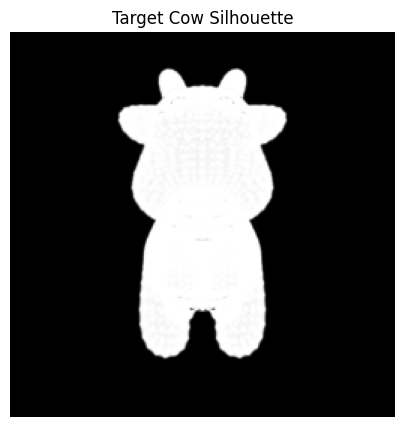

已保存: work6_assets/target_silhouette_view0.png


In [7]:
with torch.no_grad():
    target_silhouette = shader(
        rasterizer(cow_mesh.extend(num_views)),
        cow_mesh.extend(num_views),
    )[..., 3]

print("目标剪影 shape:", target_silhouette.shape)

plt.figure(figsize=(5, 5))
plt.imshow(target_silhouette[0].detach().cpu().numpy(), cmap="gray")
plt.title("Target Cow Silhouette")
plt.axis("off")

target_path = os.path.join(assets_dir, "target_silhouette_view0.png")
plt.savefig(target_path, dpi=160, bbox_inches="tight")
plt.show()

print("已保存:", target_path)

Epoch 299/300 | Total Loss: 0.014604 | Silhouette Loss: 0.009451 | Laplacian: 0.004531 | Edge: 0.004149 | Normal: 0.020740


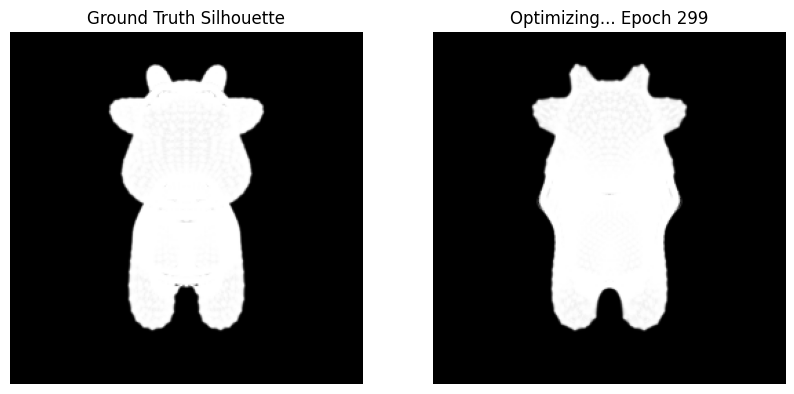

最终低难度模型已保存: work6_output_meshes/final_low_silhouette_mesh.obj
优化过程 GIF 已保存: work6_assets/low_silhouette_optimization.gif


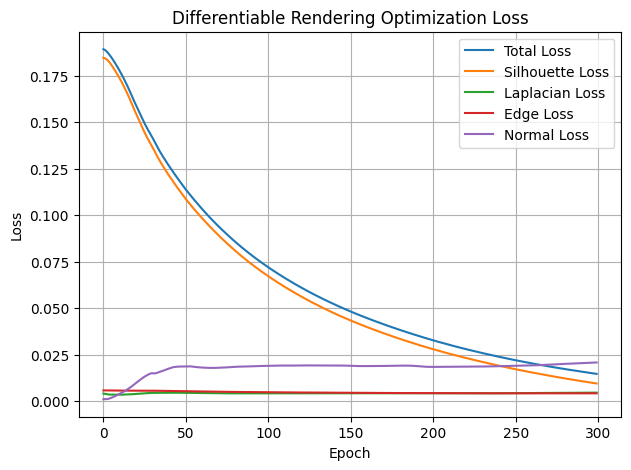

Loss 曲线已保存: work6_assets/low_loss_curve.png


In [8]:
import os
import torch
import matplotlib.pyplot as plt
import imageio.v2 as imageio

from IPython.display import clear_output
from pytorch3d.utils import ico_sphere
from pytorch3d.loss import (
    mesh_edge_loss,
    mesh_laplacian_smoothing,
    mesh_normal_consistency,
)
from pytorch3d.io import save_obj

# =========================
# 1. 初始化源模型：球体
# =========================

src_mesh = ico_sphere(4, device=device)

# deform_verts 是真正参与梯度下降的可微变量
deform_verts = torch.zeros_like(
    src_mesh.verts_packed(),
    device=device,
    requires_grad=True,
)

optimizer = torch.optim.SGD(
    [deform_verts],
    lr=1.0,
    momentum=0.9,
)

# =========================
# 2. 损失权重设置
# =========================

epochs = 300

w_lap = 1.0
w_edge = 0.1
w_normal = 0.01

loss_history = []
silhouette_history = []
lap_history = []
edge_history = []
normal_history = []

frame_paths = []
display_interval = 20

print("开始低难度剪影优化：sphere -> cow silhouette")

# =========================
# 3. 优化循环
# =========================

for i in range(epochs):
    optimizer.zero_grad()

    # 当前形变后的球体网格
    new_src_mesh = src_mesh.offset_verts(deform_verts)

    # 渲染当前网格的多视角剪影
    pred_silhouette = shader(
        rasterizer(new_src_mesh.extend(num_views)),
        new_src_mesh.extend(num_views),
    )[..., 3]

    # 剪影损失：让当前投影轮廓接近 cow.obj 的目标剪影
    loss_silhouette = ((pred_silhouette - target_silhouette) ** 2).mean()

    # 网格正则化：防止模型变成刺猬、尖刺、破碎网格
    loss_lap = mesh_laplacian_smoothing(new_src_mesh)
    loss_edge = mesh_edge_loss(new_src_mesh)
    loss_normal = mesh_normal_consistency(new_src_mesh)

    # 总损失
    loss = (
        loss_silhouette
        + w_lap * loss_lap
        + w_edge * loss_edge
        + w_normal * loss_normal
    )

    loss.backward()
    optimizer.step()

    # 记录 loss，后面用于画曲线
    loss_history.append(loss.item())
    silhouette_history.append(loss_silhouette.item())
    lap_history.append(loss_lap.item())
    edge_history.append(loss_edge.item())
    normal_history.append(loss_normal.item())

    # 定期保存图片和模型
    if i % display_interval == 0 or i == epochs - 1:
        clear_output(wait=True)

        print(
            f"Epoch {i:03d}/{epochs} | "
            f"Total Loss: {loss.item():.6f} | "
            f"Silhouette Loss: {loss_silhouette.item():.6f} | "
            f"Laplacian: {loss_lap.item():.6f} | "
            f"Edge: {loss_edge.item():.6f} | "
            f"Normal: {loss_normal.item():.6f}"
        )

        # 保存当前 OBJ
        current_verts = new_src_mesh.verts_list()[0]
        current_faces = new_src_mesh.faces_list()[0]

        obj_save_path = os.path.join(mesh_dir, f"mesh_epoch_{i:03d}.obj")
        save_obj(obj_save_path, current_verts, current_faces)

        # 保存对比图
        fig, ax = plt.subplots(1, 2, figsize=(10, 5))

        ax[0].imshow(target_silhouette[0].detach().cpu().numpy(), cmap="gray")
        ax[0].set_title("Ground Truth Silhouette")
        ax[0].axis("off")

        ax[1].imshow(pred_silhouette[0].detach().cpu().numpy(), cmap="gray")
        ax[1].set_title(f"Optimizing... Epoch {i}")
        ax[1].axis("off")

        frame_path = os.path.join(assets_dir, f"low_compare_epoch_{i:03d}.png")
        plt.savefig(frame_path, dpi=160, bbox_inches="tight")
        plt.show()

        frame_paths.append(frame_path)

# =========================
# 4. 保存最终模型
# =========================

final_mesh = src_mesh.offset_verts(deform_verts)
final_verts = final_mesh.verts_list()[0]
final_faces = final_mesh.faces_list()[0]

final_obj_path = os.path.join(mesh_dir, "final_low_silhouette_mesh.obj")
save_obj(final_obj_path, final_verts, final_faces)

print("最终低难度模型已保存:", final_obj_path)

# =========================
# 5. 生成优化过程 GIF
# =========================

frames = [imageio.imread(path) for path in frame_paths]
gif_path = os.path.join(assets_dir, "low_silhouette_optimization.gif")
imageio.mimsave(gif_path, frames, fps=4)

print("优化过程 GIF 已保存:", gif_path)

# =========================
# 6. 保存 Loss 曲线
# =========================

plt.figure(figsize=(7, 5))
plt.plot(loss_history, label="Total Loss")
plt.plot(silhouette_history, label="Silhouette Loss")
plt.plot(lap_history, label="Laplacian Loss")
plt.plot(edge_history, label="Edge Loss")
plt.plot(normal_history, label="Normal Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Differentiable Rendering Optimization Loss")
plt.legend()
plt.grid(True)

loss_curve_path = os.path.join(assets_dir, "low_loss_curve.png")
plt.savefig(loss_curve_path, dpi=160, bbox_inches="tight")
plt.show()

print("Loss 曲线已保存:", loss_curve_path)

In [ ]:
# =========================
# 0. 备份低难度版本
# =========================

!cp work6_differentiable_rendering.ipynb work6_low_silhouette.ipynb
!mkdir -p work6_high_assets
!mkdir -p work6_high_output_meshes

print("低难度 Notebook 已备份为: work6_low_silhouette.ipynb")
print("高难度图片目录: work6_high_assets")
print("高难度模型目录: work6_high_output_meshes")